# 01 — Advanced Structural Features (5m BTCUSDT)

**Task ID:** `FEAT-ENG-REBUILD-002`

Feature architecture built around market *physics* rather than indicator smoothing.
Four mathematically distinct groups, prefixed for LightGBM ablation testing:

| Group | Prefix | Theme |
|-------|--------|-------|
| A — Structure | `struct_` | Swing extrema anchors, wick rejection vectors |
| B — Liquidity | `liq_` | Anchored VWAP, rolling POC, exhaustion spikes |
| C — Volatility | `volat_` | Bollinger-Keltner squeeze, Garman-Klass estimator |
| D — MTF Context | `mtf_` | 1h/4h trend alignment, session timing |

**Input:** `data/raw/BTCUSDT_5m.parquet`, `data/raw/BTCUSDT_1h.parquet`
**Output:** `data/features/BTCUSDT_5m_structural.parquet` + `feature_registry_v2.json`

**Lookahead-bias policy:** all rolling windows use `.shift(1)` on parameters derived
from past data. Swing extrema confirmation is delayed by `order` bars.


In [1]:
from __future__ import annotations

import json
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import scipy.signal as ss

import seaborn as sns

warnings.filterwarnings("ignore")
print(f"pandas {pd.__version__} | numpy {np.__version__}")


pandas 3.0.2 | numpy 2.4.4


In [2]:
# ── Repo root ─────────────────────────────────────────────────────────────
def _repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("pyproject.toml not found")

REPO_ROOT    = _repo_root()
RAW_DIR      = REPO_ROOT / "data" / "raw"
FEATURES_DIR = REPO_ROOT / "data" / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Output paths ──────────────────────────────────────────────────────────
OUT_PARQUET  = FEATURES_DIR / "BTCUSDT_5m_structural.parquet"
OUT_REGISTRY = FEATURES_DIR / "feature_registry_v2.json"

# ── Window parameters (all in bars of the source timeframe) ───────────────
# Group A
SWING_ORDER_S = 12   # 12 × 5m = 1h each side  (minor structure)
SWING_ORDER_L = 48   # 48 × 5m = 4h each side  (major structure)
NEAR_THRESH   = 0.003  # 0.3% proximity to swing level

# Group B
VOC_WIN_S     = 72   # 72 × 5m = 6h  (short liquidity window)
VOC_WIN_L     = 288  # 288 × 5m = 24h (daily liquidity window)
POC_BINS      = 30   # price bins for rolling POC

# Group C
BB_WIN        = 20
ATR_WIN_S     = 20
ATR_WIN_L     = 72

# Group D — 1h bars
H1_EMA_FAST   = 20
H1_EMA_SLOW   = 50
H4_RSI_PERIOD = 14
BARS_PER_YEAR_5M = 365.25 * 24 * 12   # ≈ 105 192

# ── Burn-in: drop first N 5m bars where features are still warming up ────
BURN_IN = 2500   # ≈ 8.7 days of 5m data

print(f"REPO_ROOT    : {REPO_ROOT}")
print(f"OUT_PARQUET  : {OUT_PARQUET}")
print(f"OUT_REGISTRY : {OUT_REGISTRY}")


REPO_ROOT    : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
OUT_PARQUET  : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/features/BTCUSDT_5m_structural.parquet
OUT_REGISTRY : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/features/feature_registry_v2.json


In [3]:
# ── Load raw OHLCV ────────────────────────────────────────────────────────
def _load(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Run 00_data_ingestion.ipynb first."
        )
    df = pd.read_parquet(path)
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    df.index.name = "open_time"
    df = df[["open", "high", "low", "close", "volume"]].astype("float64")
    print(f"  {label:10s}: {len(df):>9,} rows | "
          f"{df.index[0].date()} → {df.index[-1].date()}")
    return df

print("Loading raw data...")
df5  = _load(RAW_DIR / "BTCUSDT_5m.parquet",  "5m BTC")
df1h = _load(RAW_DIR / "BTCUSDT_1h.parquet",  "1h BTC")

# Ensure 1h covers the 5m date range (it should, since 1h was ingested first)
assert df1h.index[0] <= df5.index[0], (
    "1h data does not cover the start of 5m data — re-run ingestion."
)
print("\nData loaded successfully.")


Loading raw data...
  5m BTC    :   923,248 rows | 2017-08-17 → 2026-05-27
  1h BTC    :    76,938 rows | 2017-08-17 → 2026-05-27

Data loaded successfully.


## Group A — Micro-Structural Price Action (`struct_`)

Translates visual chart patterns into continuous numerical vectors using confirmed
swing extrema. Avoids boolean True/False pattern labels; instead, features
describe the *geometry* of the market relative to structural reference points.

**Lookahead policy:** `argrelextrema(order=N)` requires N bars on each side of
a candidate to confirm an extremum. We delay usage by N bars, so the "last known
swing" visible at time t was confirmed at time t (and occurred at t−N).


In [4]:
def build_group_A(df: pd.DataFrame, order_s: int, order_l: int,
                  near_thresh: float) -> pd.DataFrame:
    """
    Swing-extrema anchors and wick-rejection vectors.

    Parameters
    ----------
    df         : 5m OHLCV DataFrame with UTC DatetimeIndex
    order_s    : argrelextrema order for minor structure (e.g. 12 → ±1 h)
    order_l    : argrelextrema order for major structure (e.g. 48 → ±4 h)
    near_thresh: proximity threshold for double-bottom/top detection (e.g. 0.003)
    """
    close_arr = df["close"].values
    high_arr  = df["high"].values
    low_arr   = df["low"].values
    open_arr  = df["open"].values
    n = len(df)

    feats = pd.DataFrame(index=df.index, dtype="float32")

    # ── Confirmed swing detection ─────────────────────────────────────────
    def _confirmed_extrema(arr, comparator, order):
        """
        Find local extrema and delay by `order` bars to avoid lookahead.
        Returns two Series: the confirmed extremum price, and bars-since-last.
        """
        idx = ss.argrelextrema(arr, comparator, order=order)[0]

        price_series = np.full(n, np.nan)
        for raw_i in idx:
            confirmed_at = raw_i + order
            if confirmed_at < n:
                price_series[confirmed_at] = arr[raw_i]

        # Forward-fill: propagate last known extremum forward
        s = pd.Series(price_series, index=df.index)
        ffilled = s.ffill()

        # Bars since last confirmed extremum
        is_new = s.notna()
        counter = is_new.cumsum()
        age = is_new.groupby(counter).cumcount()
        # Before first confirmed extremum: NaN
        age = age.where(counter > 0).astype("float32")

        return ffilled.astype("float32"), age

    # Minor structure (short order)
    sh_s, sh_s_age = _confirmed_extrema(high_arr, np.greater_equal, order_s)
    sl_s, sl_s_age = _confirmed_extrema(low_arr,  np.less_equal,    order_s)

    # Major structure (long order)
    sh_l, _        = _confirmed_extrema(high_arr, np.greater_equal, order_l)
    sl_l, _        = _confirmed_extrema(low_arr,  np.less_equal,    order_l)

    close = df["close"]

    # ── Distance features (signed %, > 0 = price below resistance) ───────
    feats["struct_dist_swing_high_s"] = (sh_s - close) / close
    feats["struct_dist_swing_low_s"]  = (close - sl_s) / close
    feats["struct_dist_swing_high_l"] = (sh_l - close) / close
    feats["struct_dist_swing_low_l"]  = (close - sl_l) / close

    # ── Proximity (near-double-bottom/top) flags ──────────────────────────
    feats["struct_near_swing_high_s"] = (
        feats["struct_dist_swing_high_s"].abs() < near_thresh
    ).astype("float32")
    feats["struct_near_swing_low_s"]  = (
        feats["struct_dist_swing_low_s"].abs() < near_thresh
    ).astype("float32")

    # ── Age: bars since last confirmed swing ──────────────────────────────
    feats["struct_swing_high_age_s"] = sh_s_age
    feats["struct_swing_low_age_s"]  = sl_s_age

    # ── Wick-rejection vectors ────────────────────────────────────────────
    total_range = (df["high"] - df["low"]).replace(0, np.nan)
    body_top    = df[["open", "close"]].max(axis=1)
    body_bot    = df[["open", "close"]].min(axis=1)

    feats["struct_lower_wick_ratio"] = (
        (body_bot - df["low"])  / total_range
    ).astype("float32")
    feats["struct_upper_wick_ratio"] = (
        (df["high"] - body_top) / total_range
    ).astype("float32")
    feats["struct_body_ratio"] = (
        (df["close"] - df["open"]).abs() / total_range
    ).astype("float32")

    return feats

print("Building Group A (Structure)...")
grp_A = build_group_A(df5, SWING_ORDER_S, SWING_ORDER_L, NEAR_THRESH)
print(f"  Features: {list(grp_A.columns)}")
print(f"  Shape   : {grp_A.shape} | NaN rows: {grp_A.isna().any(axis=1).sum():,}")


Building Group A (Structure)...
  Features: ['struct_dist_swing_high_s', 'struct_dist_swing_low_s', 'struct_dist_swing_high_l', 'struct_dist_swing_low_l', 'struct_near_swing_high_s', 'struct_near_swing_low_s', 'struct_swing_high_age_s', 'struct_swing_low_age_s', 'struct_lower_wick_ratio', 'struct_upper_wick_ratio', 'struct_body_ratio']
  Shape   : (923248, 11) | NaN rows: 2,356


## Group B — Liquidity & Order Flow Proxies (`liq_`)

Estimates institutional liquidity positioning from price and volume without L2
order book access. Three sub-signals:

1. **Anchored VWAP deviations** — daily and weekly VWAP reset; institutions
   benchmark execution against VWAP. Deviation = mean reversion pressure.
2. **Rolling Volume Profile POC** — price bin with maximum volume in the last
   N bars. Distance to POC acts as a gravitational attraction feature.
3. **Exhaustion spikes** — volume > 3σ above rolling mean combined with
   close direction, identifying capitulation / stop-hunt candles.

**POC implementation:** vectorized numpy cumsum subtraction (O(n × bins), no
Python loop) using globally-quantized price bins across the full series.


In [5]:
def _rolling_vwap(df: pd.DataFrame, window: int) -> pd.Series:
    """Rolling VWAP over the last `window` bars (no anchoring)."""
    tp = (df["high"] + df["low"] + df["close"]) / 3
    pv = tp * df["volume"]
    return (
        pv.rolling(window, min_periods=1).sum()
        / df["volume"].rolling(window, min_periods=1).sum()
    )

def _anchored_vwap(df: pd.DataFrame, freq: str) -> pd.Series:
    """
    VWAP anchored to each period's open (daily='D', weekly='W').
    Cumulative within each period → lookahead-free.
    """
    tp = (df["high"] + df["low"] + df["close"]) / 3
    pv = tp * df["volume"]

    if freq == "D":
        key = df.index.floor("D")
    else:  # 'W' — ISO week start (Monday)
        key = df.index.to_period("W").start_time.tz_localize("UTC")

    cum_pv  = pv.groupby(key).cumsum()
    cum_vol = df["volume"].groupby(key).cumsum()
    return (cum_pv / cum_vol.replace(0, np.nan)).astype("float64")

def _rolling_poc(close_arr: np.ndarray, vol_arr: np.ndarray,
                 window: int, n_bins: int) -> np.ndarray:
    """
    Vectorized rolling Point-of-Control.

    Strategy: globally quantize prices into n_bins buckets, build a
    (n × n_bins) volume-per-bin matrix, compute sliding window sums
    via cumsum subtraction → fully vectorized, O(n × n_bins).
    """
    n = len(close_arr)
    p_min, p_max = close_arr.min(), close_arr.max()
    edges   = np.linspace(p_min, p_max, n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2

    bar_bin = np.clip(np.digitize(close_arr, edges) - 1, 0, n_bins - 1)

    # Sparse volume matrix: each row has one non-zero entry
    vol_mat = np.zeros((n, n_bins), dtype=np.float32)
    vol_mat[np.arange(n), bar_bin] = vol_arr.astype(np.float32)

    # Cumulative volume per bin
    cum_vol = np.cumsum(vol_mat, axis=0)   # shape (n, n_bins)

    # Sliding window sum: cum[t] - cum[t - window]
    pad   = np.zeros((window, n_bins), dtype=np.float32)
    lagged = np.vstack([pad, cum_vol[:-window]])
    win_vol = cum_vol - lagged              # shape (n, n_bins)

    poc_bin = np.argmax(win_vol, axis=1)
    poc_arr = centers[poc_bin].astype(np.float32)
    poc_arr[:window] = np.nan
    return poc_arr

def build_group_B(df: pd.DataFrame, win_s: int, win_l: int,
                  poc_bins: int) -> pd.DataFrame:
    """Anchored VWAP, rolling POC, and exhaustion spike features."""
    close  = df["close"]
    volume = df["volume"]
    feats  = pd.DataFrame(index=df.index, dtype="float32")

    # ── Anchored VWAP deviations ──────────────────────────────────────────
    for tag, series in [
        ("daily",   _anchored_vwap(df, "D")),
        ("weekly",  _anchored_vwap(df, "W")),
        (f"{win_s}bar", _rolling_vwap(df, win_s)),
        (f"{win_l}bar", _rolling_vwap(df, win_l)),
    ]:
        feats[f"liq_vwap_dev_{tag}"] = (
            (close - series) / series
        ).astype("float32")

    # ── Rolling POC distance ──────────────────────────────────────────────
    close_np = close.to_numpy(dtype=np.float64)
    vol_np   = volume.to_numpy(dtype=np.float64)

    for win, tag in [(win_s, f"{win_s}bar"), (win_l, f"{win_l}bar")]:
        poc = _rolling_poc(close_np, vol_np, win, poc_bins)
        feats[f"liq_poc_dist_{tag}"] = (
            (close_np - poc) / poc
        ).astype("float32")

    # ── Volume z-score (parameters from past; current vol as signal) ──────
    for win, tag in [(win_s, f"{win_s}bar"), (win_l, f"{win_l}bar")]:
        v_mean = volume.rolling(win, min_periods=win//2).mean().shift(1)
        v_std  = volume.rolling(win, min_periods=win//2).std().shift(1)
        z      = ((volume - v_mean) / v_std.replace(0, np.nan))
        feats[f"liq_vol_z_{tag}"] = z.clip(-5, 5).astype("float32")

    # ── Exhaustion spikes: vol > 3σ & directional close ──────────────────
    z_l   = feats[f"liq_vol_z_{win_l}bar"]
    body  = (df["close"] - df["open"]).astype("float32")
    feats["liq_exhaustion_bull"] = ((z_l > 3) & (body > 0)).astype("float32")
    feats["liq_exhaustion_bear"] = ((z_l > 3) & (body < 0)).astype("float32")

    return feats

print("Building Group B (Liquidity) — POC step is vectorized but matrix-heavy...")
grp_B = build_group_B(df5, VOC_WIN_S, VOC_WIN_L, POC_BINS)
print(f"  Features: {list(grp_B.columns)}")
print(f"  Shape   : {grp_B.shape} | NaN rows: {grp_B.isna().any(axis=1).sum():,}")


Building Group B (Liquidity) — POC step is vectorized but matrix-heavy...
  Features: ['liq_vwap_dev_daily', 'liq_vwap_dev_weekly', 'liq_vwap_dev_72bar', 'liq_vwap_dev_288bar', 'liq_poc_dist_72bar', 'liq_poc_dist_288bar', 'liq_vol_z_72bar', 'liq_vol_z_288bar', 'liq_exhaustion_bull', 'liq_exhaustion_bear']
  Shape   : (923248, 10) | NaN rows: 795


## Group C — Volatility Squeeze & Regime Vectors (`volat_`)

Tells the model whether the market is trending or coiling for a breakout.

**Bollinger-Keltner Squeeze:** compares Bollinger Band width (standard-deviation
based) against Keltner Channel width (ATR-based).
$$\text{SqueezeRatio} = \frac{4 \times \sigma_{20}}{2 \times ATR_{20}}$$
When this ratio < 1.0, price volatility is compressed inside ATR — classic
pre-breakout squeeze.

**Garman-Klass estimator:** incorporates High, Low, Open, Close to estimate
intra-bar variance more efficiently than close-to-close returns:
$$GK = 0.5 \ln\!\left(\frac{H}{L}\right)^2 - (2\ln 2 - 1)\ln\!\left(\frac{C}{O}\right)^2$$


In [6]:
def build_group_C(df: pd.DataFrame, bb_win: int,
                  atr_win_s: int, atr_win_l: int,
                  bars_per_year: float) -> pd.DataFrame:
    """Bollinger-Keltner squeeze, Garman-Klass volatility, ATR regime."""
    feats = pd.DataFrame(index=df.index, dtype="float32")
    close = df["close"]
    high  = df["high"]
    low   = df["low"]
    open_ = df["open"]

    # ── True Range & ATR ──────────────────────────────────────────────────
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs(),
    ], axis=1).max(axis=1)

    for win, tag in [(atr_win_s, f"{atr_win_s}"), (atr_win_l, f"{atr_win_l}")]:
        atr = tr.rolling(win, min_periods=win//2).mean()
        feats[f"volat_atr_{tag}_pct"] = (atr / close).astype("float32")

    atr_s = tr.rolling(atr_win_s, min_periods=atr_win_s // 2).mean()

    # ── Bollinger Bands (20-period) ───────────────────────────────────────
    sma20 = close.rolling(bb_win, min_periods=bb_win // 2).mean()
    std20 = close.rolling(bb_win, min_periods=bb_win // 2).std()

    bb_upper  = sma20 + 2 * std20
    bb_lower  = sma20 - 2 * std20
    bb_width  = 4 * std20                              # total BB span

    feats["volat_bb_width_20"] = (bb_width / close).astype("float32")
    feats["volat_bb_position_20"] = (
        (close - bb_lower) / (bb_width.replace(0, np.nan))
    ).clip(0, 1).astype("float32")

    # ── Keltner Channel (EMA20 ± 1.5 × ATR20) ────────────────────────────
    ema20    = close.ewm(span=bb_win, adjust=False).mean()
    kc_width = 2 * 1.5 * atr_s                        # total KC span

    # ── Bollinger-Keltner Squeeze Ratio ──────────────────────────────────
    squeeze_ratio = (bb_width / kc_width.replace(0, np.nan))
    feats["volat_bk_squeeze"] = squeeze_ratio.clip(0, 3).astype("float32")
    feats["volat_squeeze_on"] = (squeeze_ratio < 1.0).astype("float32")

    # ── Garman-Klass estimator ────────────────────────────────────────────
    log_hl  = np.log(high / low.replace(0, np.nan))
    log_co  = np.log(close / open_.replace(0, np.nan))
    gk_bar  = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2

    for win, tag in [(atr_win_s, f"{atr_win_s}"), (atr_win_l, f"{atr_win_l}")]:
        gk_roll = gk_bar.rolling(win, min_periods=win // 2).mean()
        # Annualized volatility for this bar-size
        feats[f"volat_gk_{tag}"] = (
            np.sqrt(gk_roll * bars_per_year)
        ).astype("float32")

    return feats

print("Building Group C (Volatility)...")
grp_C = build_group_C(df5, BB_WIN, ATR_WIN_S, ATR_WIN_L, BARS_PER_YEAR_5M)
print(f"  Features: {list(grp_C.columns)}")
print(f"  Shape   : {grp_C.shape} | NaN rows: {grp_C.isna().any(axis=1).sum():,}")


Building Group C (Volatility)...
  Features: ['volat_atr_20_pct', 'volat_atr_72_pct', 'volat_bb_width_20', 'volat_bb_position_20', 'volat_bk_squeeze', 'volat_squeeze_on', 'volat_gk_20', 'volat_gk_72']
  Shape   : (923248, 8) | NaN rows: 137


## Group D — Macro-Context & MTF Alignment (`mtf_`)

A 5-minute signal in isolation is noise. These features impose a higher-timeframe
filter so the model only acts when structure is aligned.

**MTF alignment score:** continuous EMA spread (not discrete ±1 sign) on 1h and
4h — richer signal than a binary trend flag.

**Mapping down:** `1h_series.reindex(5m_index, method='ffill')` propagates the
*last known* higher-timeframe value forward, never forward-filling future data.
A new 4h candle at 08:00 UTC only becomes visible at 08:00 UTC.

**Session timing:** sine/cosine encoding of UTC hour and day-of-week captures
London (08:00–16:00 UTC), New York (13:00–21:00 UTC), and Asian (00:00–08:00 UTC)
session overlaps that dominate BTC liquidity.


In [7]:
def _wilder_rsi(series: pd.Series, period: int) -> pd.Series:
    """Wilder-smoothed RSI (matches TradingView / industry standard)."""
    delta = series.diff()
    up    = delta.clip(lower=0)
    dn    = (-delta).clip(lower=0)
    ema_u = up.ewm(com=period - 1, adjust=False, min_periods=period).mean()
    ema_d = dn.ewm(com=period - 1, adjust=False, min_periods=period).mean()
    rs    = ema_u / ema_d.replace(0, np.nan)
    return (100 - 100 / (1 + rs)).astype("float32")

def _ema_spread(close: pd.Series, fast: int, slow: int) -> pd.Series:
    """Normalized EMA spread: (EMA_fast - EMA_slow) / close. Continuous signal."""
    ema_f = close.ewm(span=fast, adjust=False).mean()
    ema_s = close.ewm(span=slow, adjust=False).mean()
    return ((ema_f - ema_s) / close).astype("float32")

def build_group_D(df5m: pd.DataFrame, df1h: pd.DataFrame,
                  ema_fast: int, ema_slow: int,
                  rsi_period: int) -> pd.DataFrame:
    """MTF trend signals (1h and 4h) mapped to 5m index + session timing."""
    feats = pd.DataFrame(index=df5m.index, dtype="float32")
    idx5  = df5m.index

    # ── 1-Hour features ───────────────────────────────────────────────────
    h1_close  = df1h["close"]
    h1_spread = _ema_spread(h1_close, ema_fast, ema_slow)
    h1_rsi    = _wilder_rsi(h1_close, rsi_period)
    h1_above  = (h1_close > h1_close.ewm(span=ema_slow, adjust=False).mean()
                 ).astype("float32")

    # .shift(1) is MANDATORY before reindex:
    # df1h bar labeled "10:00" has open_time=10:00 and closes at ~10:59.
    # Without shift, 5m bars 10:00–10:55 receive EMA/RSI from prices up to
    # 10:59 — up to 55 min of lookahead. shift(1) assigns those bars the
    # PREVIOUS 1h bar's value (closed at 10:00 and fully known from 10:00).
    feats["mtf_h1_ema_signal"]  = h1_spread.shift(1).reindex(idx5, method="ffill")
    feats["mtf_h1_rsi"]         = (h1_rsi / 100).shift(1).reindex(idx5, method="ffill")
    feats["mtf_h1_above_ema50"] = h1_above.shift(1).reindex(idx5, method="ffill")

    # ── 4-Hour features (resample 1h → 4h, then map to 5m) ───────────────
    # Same lookahead concern: "08:00" 4h bar closes at ~11:59.
    # shift(1) ensures 5m bars 08:00–11:55 use the PREVIOUS 4h bar's value.
    h4_close  = df1h["close"].resample("4h", closed="left", label="left").last().dropna()
    h4_spread = _ema_spread(h4_close, ema_fast, ema_slow)
    h4_rsi    = _wilder_rsi(h4_close, rsi_period)

    feats["mtf_h4_ema_signal"] = h4_spread.shift(1).reindex(idx5, method="ffill")
    feats["mtf_h4_rsi"]        = (h4_rsi / 100).shift(1).reindex(idx5, method="ffill")

    # ── Composite alignment: weighted average of 1h and 4h EMA signals ───
    # Clip to [-0.05, 0.05] (typical normalized EMA spread range), then scale
    h1_clip = feats["mtf_h1_ema_signal"].clip(-0.05, 0.05) / 0.05
    h4_clip = feats["mtf_h4_ema_signal"].clip(-0.05, 0.05) / 0.05
    feats["mtf_alignment"] = (0.4 * h1_clip + 0.6 * h4_clip).astype("float32")

    # ── Session timing: cyclical encoding ─────────────────────────────────
    hour = idx5.hour + idx5.minute / 60.0
    dow  = idx5.dayofweek.astype(float)  # 0=Mon, 6=Sun

    feats["mtf_session_hour_sin"] = np.sin(2 * np.pi * hour / 24).astype("float32")
    feats["mtf_session_hour_cos"] = np.cos(2 * np.pi * hour / 24).astype("float32")
    feats["mtf_session_dow_sin"]  = np.sin(2 * np.pi * dow  /  7).astype("float32")
    feats["mtf_session_dow_cos"]  = np.cos(2 * np.pi * dow  /  7).astype("float32")

    return feats

print("Building Group D (MTF Context)...")
grp_D = build_group_D(df5, df1h, H1_EMA_FAST, H1_EMA_SLOW, H4_RSI_PERIOD)
print(f"  Features: {list(grp_D.columns)}")
print(f"  Shape   : {grp_D.shape} | NaN rows: {grp_D.isna().any(axis=1).sum():,}")


Building Group D (MTF Context)...
  Features: ['mtf_h1_ema_signal', 'mtf_h1_rsi', 'mtf_h1_above_ema50', 'mtf_h4_ema_signal', 'mtf_h4_rsi', 'mtf_alignment', 'mtf_session_hour_sin', 'mtf_session_hour_cos', 'mtf_session_dow_sin', 'mtf_session_dow_cos']
  Shape   : (923248, 10) | NaN rows: 720


In [8]:
# ── Assemble all groups ───────────────────────────────────────────────────
print("Assembling feature matrix...")
feat_df = pd.concat([grp_A, grp_B, grp_C, grp_D], axis=1)

# ── NaN handling ─────────────────────────────────────────────────────────
# 1. Drop the warm-up burn-in period at the start
feat_df = feat_df.iloc[BURN_IN:].copy()
n_before = len(feat_df)

# 2. Forward-fill any remaining structural NaNs (isolated missing bars)
feat_df = feat_df.ffill()

# 3. Drop rows where ANY feature is still NaN (extreme early-data edge cases)
feat_df = feat_df.dropna()
n_after  = len(feat_df)

print(f"  After burn-in drop ({BURN_IN} bars) : {n_before:>10,} rows")
print(f"  After dropna                        : {n_after:>10,} rows")
print(f"  Rows removed by dropna              : {n_before - n_after:>10,}")
print(f"  Total features                      : {feat_df.shape[1]}")
print(f"  Date range : {feat_df.index[0].date()} → {feat_df.index[-1].date()}")

# ── Sanity checks ─────────────────────────────────────────────────────────
assert not feat_df.index.duplicated().any(), "Duplicate timestamps in output!"
assert feat_df.isna().sum().sum() == 0, "NaN values remain in output!"
print("\n✓  No duplicate timestamps.")
print("✓  Zero NaN values in final feature matrix.")


Assembling feature matrix...
  After burn-in drop (2500 bars) :    920,748 rows
  After dropna                        :    920,748 rows
  Rows removed by dropna              :          0
  Total features                      : 39
  Date range : 2017-08-25 → 2026-05-27

✓  No duplicate timestamps.
✓  Zero NaN values in final feature matrix.


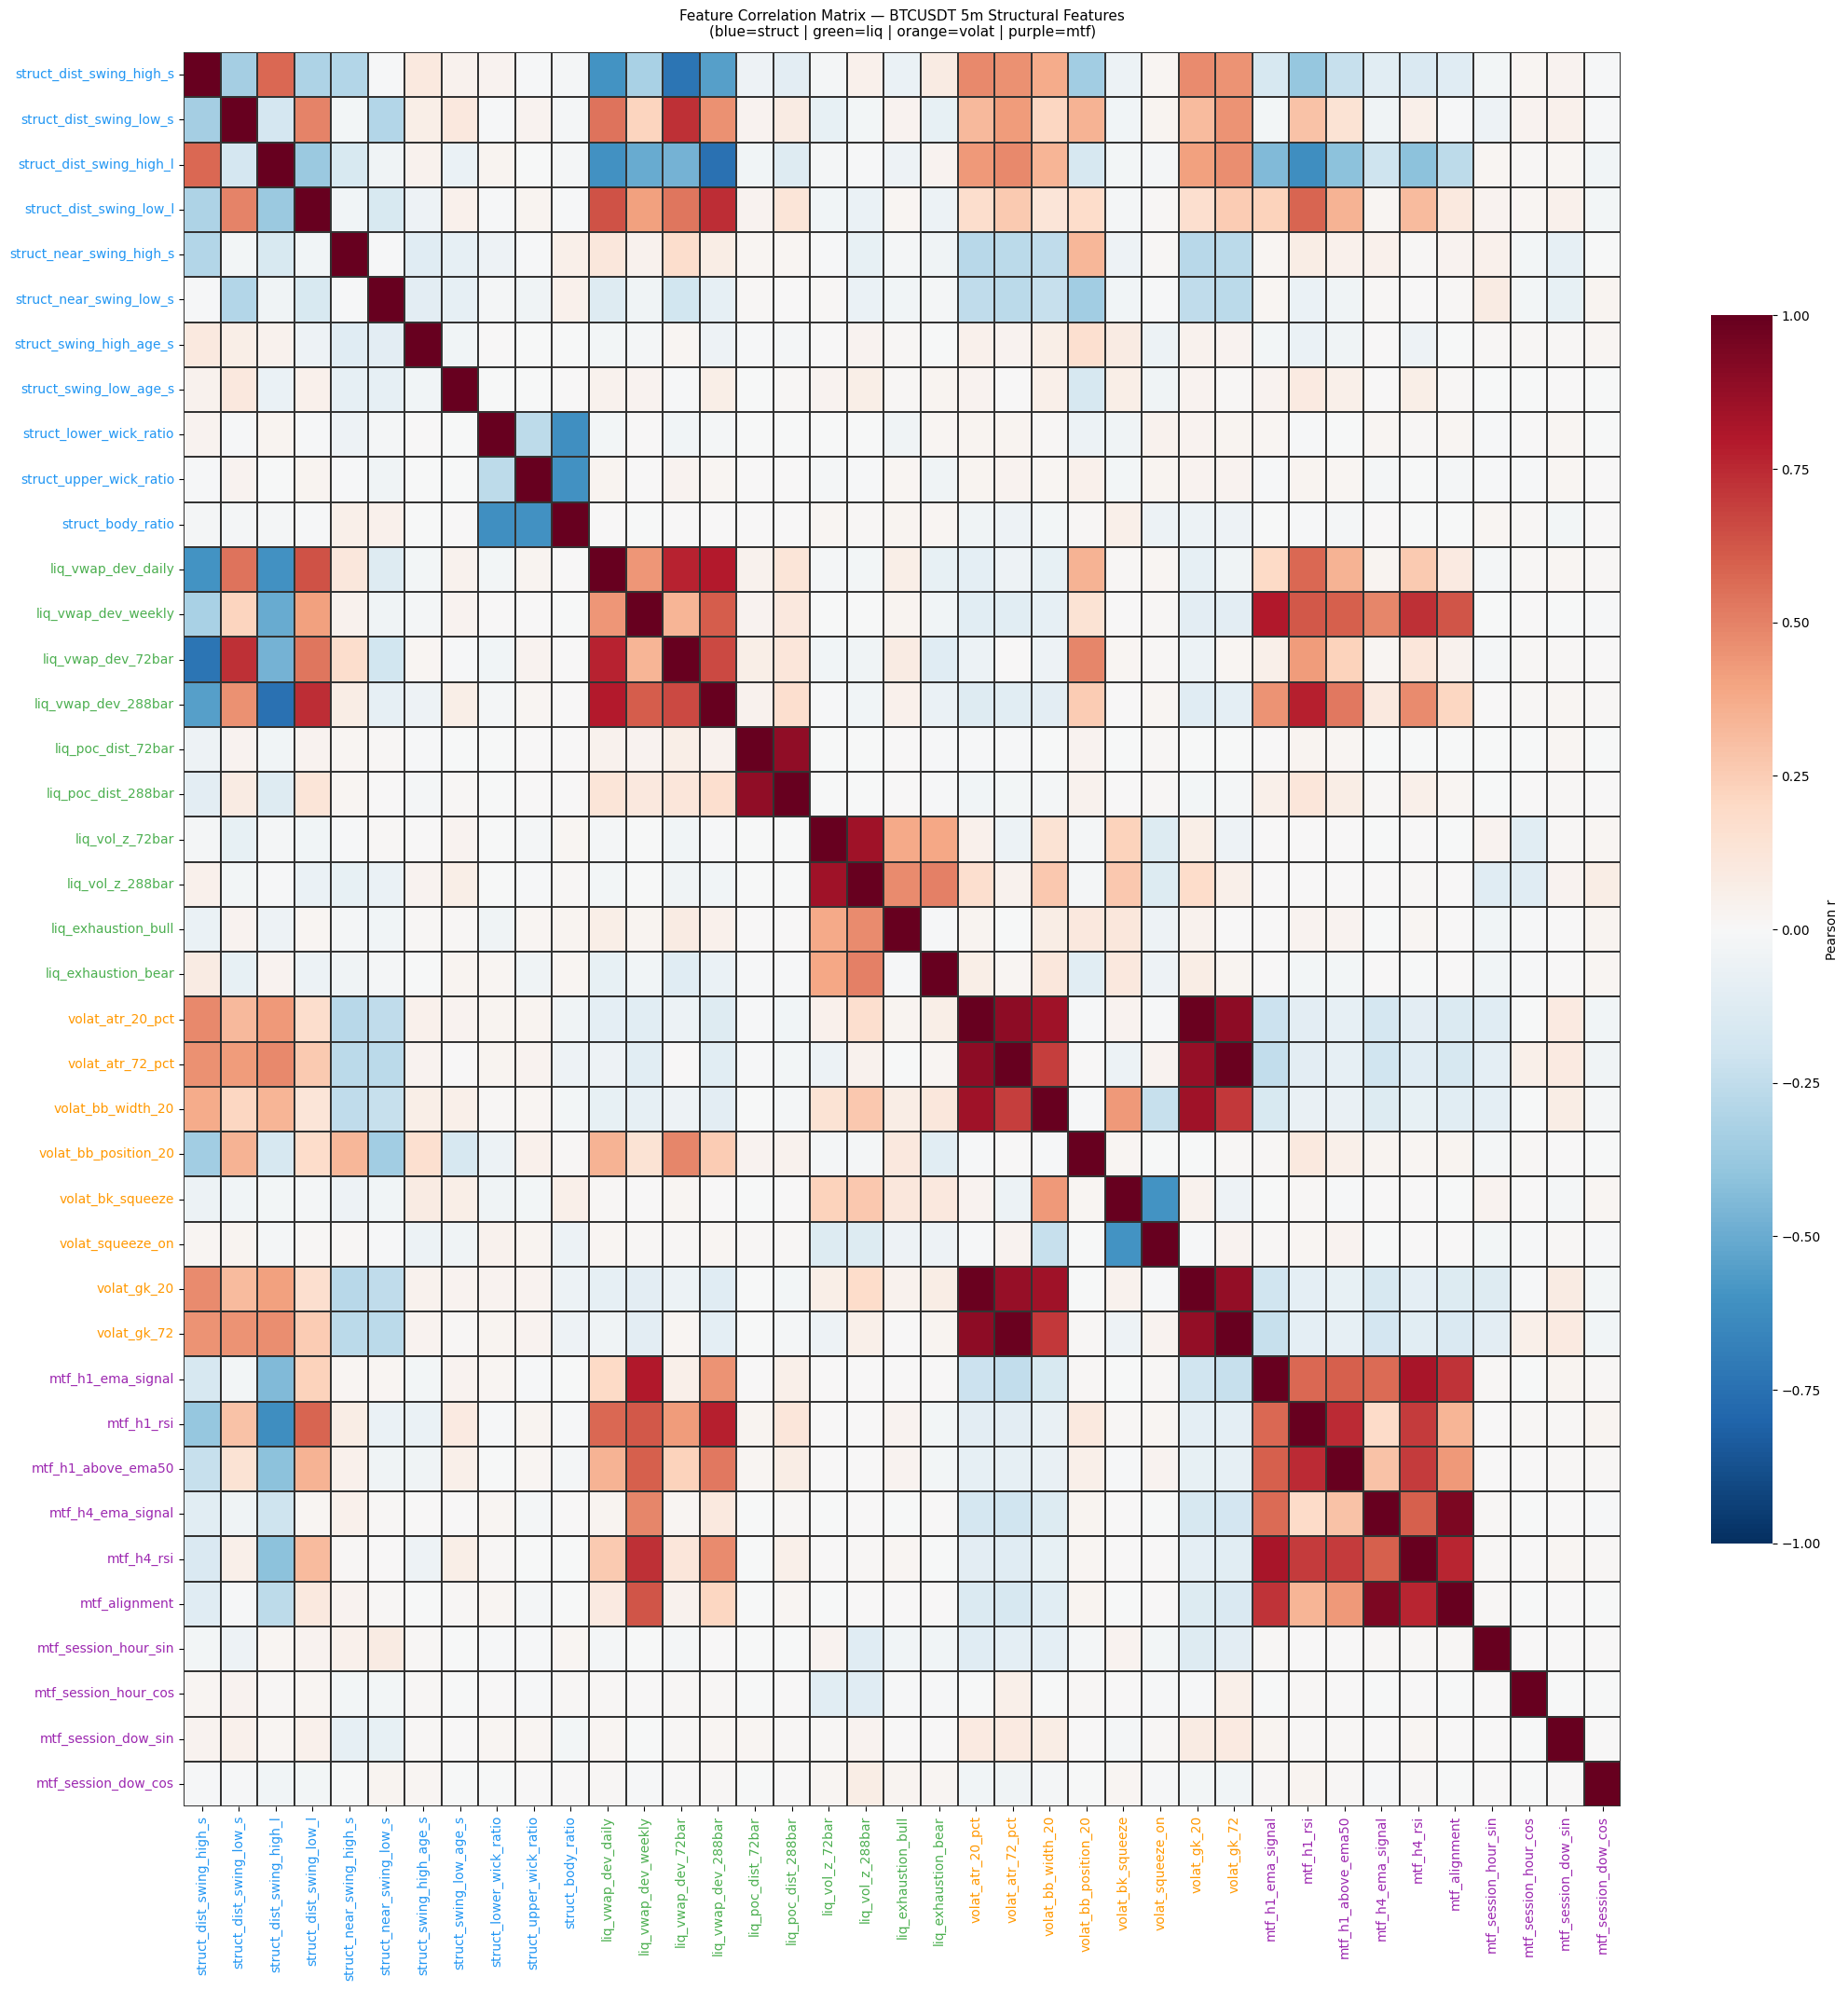

Heatmap saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/features/feature_correlation_heatmap.png

High-correlation pairs (|r| > 0.85) — consider ablation:
  volat_gk_20                              ↔  volat_atr_20_pct                          r=+0.988
  volat_gk_72                              ↔  volat_atr_72_pct                          r=+0.986
  mtf_alignment                            ↔  mtf_h4_ema_signal                         r=+0.938
  volat_atr_72_pct                         ↔  volat_atr_20_pct                          r=+0.898
  volat_gk_72                              ↔  volat_atr_20_pct                          r=+0.896
  liq_poc_dist_288bar                      ↔  liq_poc_dist_72bar                        r=+0.890
  volat_gk_72                              ↔  volat_gk_20                               r=+0.882
  volat_gk_20                              ↔  volat_atr_72_pct                          r=+0.868
  volat_gk_20                        

In [9]:
# ── Correlation heatmap ───────────────────────────────────────────────────
# Sample for speed (heatmap on 420k rows is identical to 20k)
sample = feat_df.sample(min(20_000, len(feat_df)), random_state=42)
corr   = sample.corr().astype("float32")

# Group color bands for axis labels
group_prefix = {
    "struct_": "#2196F3",  # blue
    "liq_":    "#4CAF50",  # green
    "volat_":  "#FF9800",  # orange
    "mtf_":    "#9C27B0",  # purple
}

n_feats = len(corr)
fig, ax = plt.subplots(figsize=(max(12, n_feats * 0.55),
                                max(10, n_feats * 0.55)))

sns.heatmap(
    corr, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor="#333",
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
    xticklabels=True, yticklabels=True,
)

# Color-code tick labels by group
def _color_labels(labels, axis_labels):
    for lbl in axis_labels:
        text = lbl.get_text()
        for prefix, color in group_prefix.items():
            if text.startswith(prefix):
                lbl.set_color(color)
                break

_color_labels(corr.columns, ax.get_xticklabels())
_color_labels(corr.columns, ax.get_yticklabels())

ax.set_title(
    "Feature Correlation Matrix — BTCUSDT 5m Structural Features\n"
    "(blue=struct | green=liq | orange=volat | purple=mtf)",
    fontsize=11, pad=12,
)
plt.tight_layout()
plt.savefig(FEATURES_DIR / "feature_correlation_heatmap.png", dpi=120,
            bbox_inches="tight")
plt.show()
print(f"Heatmap saved → {FEATURES_DIR / 'feature_correlation_heatmap.png'}")

# High-correlation pairs (|r| > 0.85) — flag potential redundancy
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [(c, r, upper.loc[r, c])
             for c in upper.columns for r in upper.index
             if pd.notna(upper.loc[r, c]) and abs(upper.loc[r, c]) > 0.85]
if high_corr:
    print(f"\nHigh-correlation pairs (|r| > 0.85) — consider ablation:")
    for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f"  {a:40s} ↔  {b:40s}  r={r:+.3f}")
else:
    print("\n✓ No feature pairs with |r| > 0.85 — groups are well-diversified.")


In [10]:
# ── Memory & statistics summary ───────────────────────────────────────────
print("=" * 65)
print("FEATURE MATRIX SUMMARY")
print("=" * 65)

mem_mb = feat_df.memory_usage(deep=True).sum() / 1e6

print(f"  Rows             : {len(feat_df):>12,}")
print(f"  Features         : {feat_df.shape[1]:>12,}")
print(f"  Memory (in-RAM)  : {mem_mb:>11.2f} MB")
print(f"  Date range       : {feat_df.index[0].date()} → {feat_df.index[-1].date()}")
print(f"  Timeframe        : 5-minute (BTCUSDT)")
print()

# Per-group counts
groups = {
    "A — Structure" : [c for c in feat_df.columns if c.startswith("struct_")],
    "B — Liquidity" : [c for c in feat_df.columns if c.startswith("liq_")],
    "C — Volatility": [c for c in feat_df.columns if c.startswith("volat_")],
    "D — MTF"       : [c for c in feat_df.columns if c.startswith("mtf_")],
}
print(f"  {'Group':<20} {'Count':>6}  {'NaN %':>8}  {'Mean abs':>10}")
print(f"  {'─'*20} {'─'*6}  {'─'*8}  {'─'*10}")
for gname, cols in groups.items():
    sub    = feat_df[cols]
    nan_pct = sub.isna().mean().mean() * 100
    mean_abs = sub.abs().mean().mean()
    print(f"  {gname:<20} {len(cols):>6}  {nan_pct:>7.2f}%  {mean_abs:>10.5f}")
print()

# Descriptive stats for a few representative features per group
rep_cols = [cols[0] for cols in groups.values() if cols]
print("Representative feature stats:")
print(feat_df[rep_cols].describe().round(4).to_string())


FEATURE MATRIX SUMMARY
  Rows             :      920,748
  Features         :           39
  Memory (in-RAM)  :      165.73 MB
  Date range       : 2017-08-25 → 2026-05-27
  Timeframe        : 5-minute (BTCUSDT)

  Group                 Count     NaN %    Mean abs
  ──────────────────── ──────  ────────  ──────────
  A — Structure            11     0.00%     3.97672
  B — Liquidity            10     0.00%     0.15986
  C — Volatility            8     0.00%     0.41749
  D — MTF                  10     0.00%     0.43753

Representative feature stats:
       struct_dist_swing_high_s  liq_vwap_dev_daily  volat_atr_20_pct  mtf_h1_ema_signal
count               920748.0000         920748.0000       920748.0000        920748.0000
mean                     0.0076              0.0005            0.0026             0.0002
std                      0.0142              0.0123            0.0023             0.0131
min                     -0.1734             -0.2620            0.0000            -0.2057

In [11]:
# ── Feature Registry v2 ───────────────────────────────────────────────────
groups_for_registry = {
    "A_structure": {
        "description": (
            "Micro-structural price action: confirmed swing extrema anchors "
            "and wick-rejection vectors. Distance features are signed % of close."
        ),
        "prefix": "struct_",
        "parameters": {
            "swing_order_minor": SWING_ORDER_S,
            "swing_order_major": SWING_ORDER_L,
            "near_threshold":    NEAR_THRESH,
        },
        "features": sorted([c for c in feat_df.columns if c.startswith("struct_")]),
    },
    "B_liquidity": {
        "description": (
            "Liquidity and order flow proxies: anchored VWAP deviations (daily, "
            "weekly, rolling), rolling Volume-Profile POC distance, and "
            "volume-exhaustion spike indicators."
        ),
        "prefix": "liq_",
        "parameters": {
            "voc_window_short": VOC_WIN_S,
            "voc_window_long":  VOC_WIN_L,
            "poc_bins":         POC_BINS,
        },
        "features": sorted([c for c in feat_df.columns if c.startswith("liq_")]),
    },
    "C_volatility": {
        "description": (
            "Volatility squeeze and regime vectors: Bollinger-Keltner squeeze "
            "ratio, Garman-Klass historical volatility estimator (annualized), "
            "ATR-normalized regime width."
        ),
        "prefix": "volat_",
        "parameters": {
            "bb_window":   BB_WIN,
            "atr_window_s": ATR_WIN_S,
            "atr_window_l": ATR_WIN_L,
        },
        "features": sorted([c for c in feat_df.columns if c.startswith("volat_")]),
    },
    "D_mtf": {
        "description": (
            "Macro context and multi-timeframe alignment: normalized 1h and 4h "
            "EMA-spread signals mapped to 5m via ffill, RSI, composite alignment "
            "score, and UTC session cyclical encodings."
        ),
        "prefix": "mtf_",
        "parameters": {
            "ema_fast":   H1_EMA_FAST,
            "ema_slow":   H1_EMA_SLOW,
            "rsi_period": H4_RSI_PERIOD,
        },
        "features": sorted([c for c in feat_df.columns if c.startswith("mtf_")]),
    },
}

registry = {
    "schema_version":  2,
    "created_utc":     datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    "description":     (
        "Advanced structural features for BTCUSDT 5m, grouped for "
        "LightGBM ablation testing."
    ),
    "source_assets":   ["BTCUSDT"],
    "source_timeframes": ["5m", "1h", "4h"],
    "output_parquet":  str(OUT_PARQUET),
    "burn_in_bars":    BURN_IN,
    "total_features":  feat_df.shape[1],
    "row_count":       len(feat_df),
    "date_range": {
        "start": feat_df.index[0].isoformat(),
        "end":   feat_df.index[-1].isoformat(),
    },
    "feature_groups":  groups_for_registry,
    "ablation_subsets": {
        "all":              list(feat_df.columns),
        "structure_only":   groups_for_registry["A_structure"]["features"],
        "liquidity_only":   groups_for_registry["B_liquidity"]["features"],
        "volatility_only":  groups_for_registry["C_volatility"]["features"],
        "mtf_only":         groups_for_registry["D_mtf"]["features"],
        "no_mtf":           (
            groups_for_registry["A_structure"]["features"]
            + groups_for_registry["B_liquidity"]["features"]
            + groups_for_registry["C_volatility"]["features"]
        ),
        "market_structure": (
            groups_for_registry["A_structure"]["features"]
            + groups_for_registry["B_liquidity"]["features"]
        ),
    },
}

with open(OUT_REGISTRY, "w") as f:
    json.dump(registry, f, indent=2, default=str)

print(f"Feature registry v2 written → {OUT_REGISTRY}")
print(f"  Total features : {registry['total_features']}")
print(f"  Groups         : {list(groups_for_registry.keys())}")
print(f"  Ablation sets  : {list(registry['ablation_subsets'].keys())}")


Feature registry v2 written → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/features/feature_registry_v2.json
  Total features : 39
  Groups         : ['A_structure', 'B_liquidity', 'C_volatility', 'D_mtf']
  Ablation sets  : ['all', 'structure_only', 'liquidity_only', 'volatility_only', 'mtf_only', 'no_mtf', 'market_structure']


In [12]:
# ── Serialize to Parquet ─────────────────────────────────────────────────
feat_df.to_parquet(OUT_PARQUET)
size_mb = OUT_PARQUET.stat().st_size / 1e6

# ── Round-trip validation ────────────────────────────────────────────────
check = pd.read_parquet(OUT_PARQUET)
assert check.shape == feat_df.shape, "Round-trip shape mismatch!"
assert check.isna().sum().sum() == 0, "Round-trip NaN check failed!"

print("=" * 65)
print("FINAL STORAGE REPORT")
print("=" * 65)
print(f"  File       : {OUT_PARQUET}")
print(f"  Size       : {size_mb:.2f} MB")
print(f"  Rows       : {len(feat_df):,}")
print(f"  Features   : {feat_df.shape[1]}")
print(f"  Date range : {feat_df.index[0].date()} → {feat_df.index[-1].date()}")
print(f"  Registry   : {OUT_REGISTRY}")
print()
print("✓  Round-trip parquet validation passed.")
print("✓  Feature engineering pipeline complete.")


FINAL STORAGE REPORT
  File       : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/features/BTCUSDT_5m_structural.parquet
  Size       : 114.39 MB
  Rows       : 920,748
  Features   : 39
  Date range : 2017-08-25 → 2026-05-27
  Registry   : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/features/feature_registry_v2.json

✓  Round-trip parquet validation passed.
✓  Feature engineering pipeline complete.


## Note: Target Label Design (for next notebook)

The recommended label for this feature set is an **ATR-anchored Triple Barrier**
computed in the next notebook (`03_lgbm_structural_v1.ipynb`):

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| TP barrier | 2.0 × ATR₁₄ (1h) | Adapts to volatility regime |
| SL barrier | 1.0 × ATR₁₄ (1h) | Asymmetric 2:1 → profitable at 35% win rate |
| Time barrier | 72 bars = 6h | MTF-confirmed moves; avoids noise scalping |
| Label `+1` | Long TP hit first | Directional bull trade |
| Label `−1` | Short TP hit first | Directional bear trade |
| Label `0` | Timeout (neither) | **Abstain signal** — model learns *not* to trade |

The `0` class is the most valuable: it teaches the model that the optimal decision
in a ranging, compressed market is to hold cash, not to force a trade.

**Mapping 1h ATR to 5m index:**
```python
atr_1h = true_range_1h.rolling(14).mean()
atr_5m  = atr_1h.reindex(df5m.index, method='ffill')  # lookahead-free
```

For the `mtf_alignment` feature, a minimum threshold of `0.3` (30% aligned) is
suggested as a pre-filter before applying the triple barrier, reducing label noise
in directionless regimes.
